In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanmidev/smart-meters-in-london/darksky_parameters_documentation.html
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_hourly_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/acorn_details.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/uk_bank_holidays.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_daily_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/informations_households.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_97.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_27.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_55.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_0.csv
/kaggle/input/datasets/jeanmi

In [ ]:
# Daily weather data is used to align with the daily aggregation of energy consumption,
# It is expected to influence energy consumption, particularly heating and cooling demands.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_daily_darksky.csv')
df.head()

,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,...,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
0,11.96,2011-11-11 23:00:00,123,fog,9.40,2011-11-11 07:00:00,0.79,3.88,1016.08,2011-11-11 07:00:00,...,10.87,2011-11-11 07:12:14,2011-11-11 19:00:00,2011-11-11 11:00:00,Foggy until afternoon.,2011-11-11 19:00:00,6.48,2011-11-11 23:00:00,2011-11-11 19:00:00,0.52
1,8.59,2011-12-11 14:00:00,198,partly-cloudy-day,4.49,2011-12-11 01:00:00,0.56,3.94,1007.71,2011-12-11 02:00:00,...,8.59,2011-12-11 07:57:02,2011-12-11 14:00:00,2011-12-11 12:00:00,Partly cloudy throughout the day.,2011-12-12 07:00:00,0.11,2011-12-11 20:00:00,2011-12-12 08:00:00,0.53
2,10.33,2011-12-27 02:00:00,225,partly-cloudy-day,5.47,2011-12-27 23:00:00,0.85,3.54,1032.76,2011-12-27 22:00:00,...,10.33,2011-12-27 08:07:06,2011-12-27 14:00:00,2011-12-27 00:00:00,Mostly cloudy throughout the day.,2011-12-27 23:00:00,5.59,2011-12-27 02:00:00,2011-12-28 00:00:00,0.10
3,8.07,2011-12-02 23:00:00,232,wind,3.69,2011-12-02 07:00:00,0.32,3.00,1012.12,2011-12-02 07:00:00,...,7.36,2011-12-02 07:46:09,2011-12-02 12:00:00,2011-12-02 10:00:00,Partly cloudy throughout the day and breezy ov...,2011-12-02 19:00:00,0.46,2011-12-02 12:00:00,2011-12-02 19:00:00,0.25
4,8.22,2011-12-24 23:00:00,252,partly-cloudy-night,2.79,2011-12-24 07:00:00,0.37,4.46,1028.17,2011-12-24 07:00:00,...,7.93,2011-12-24 08:06:15,2011-12-24 15:00:00,2011-12-24 13:00:00,Mostly cloudy throughout the day.,2011-12-24 19:00:00,-0.51,2011-12-24 23:00:00,2011-12-24 20:00:00,0.99


In [5]:
# approximate data for 2.4 years
df.shape

(882, 32)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperatureMax               882 non-null    float64
 1   temperatureMaxTime           882 non-null    object 
 2   windBearing                  882 non-null    int64  
 3   icon                         882 non-null    object 
 4   dewPoint                     882 non-null    float64
 5   temperatureMinTime           882 non-null    object 
 6   cloudCover                   881 non-null    float64
 7   windSpeed                    882 non-null    float64
 8   pressure                     882 non-null    float64
 9   apparentTemperatureMinTime   882 non-null    object 
 10  apparentTemperatureHigh      882 non-null    float64
 11  precipType                   882 non-null    object 
 12  visibility                   882 non-null    float64
 13  humidity            

In [8]:
df['time'] = pd.to_datetime(df['time'])
df = df.rename(columns={'time': 'day'})

In [9]:
# Performing feature selection on the weather dataset by retaining variables that directly influence energy consumption, 
# such as temperature and humidity, while removing redundant and non-informative columns.
cols_to_keep = ['day',  'temperatureMax','temperatureMin','humidity','windSpeed','cloudCover','apparentTemperatureMax','apparentTemperatureMin']

df = df[cols_to_keep]

In [11]:
# Filling missing value with previous day’s value as weather changes gradually
# It preserves time continuity
df = df.ffill()

In [16]:
# Sorting data according to day
df = df.sort_values(by='day')
df = df.reset_index(drop=True)

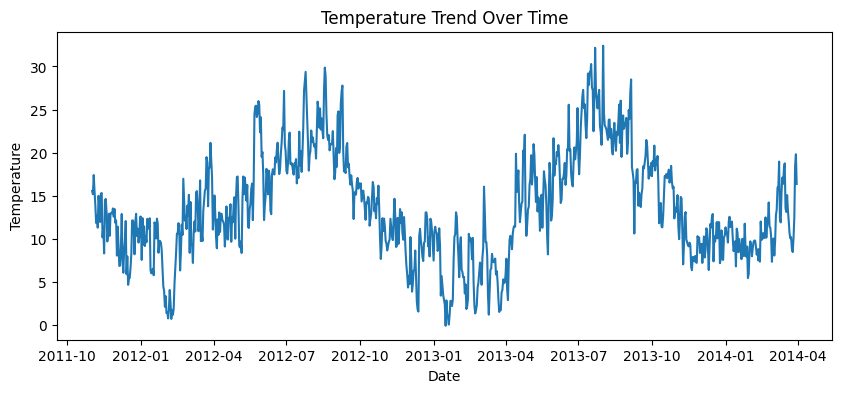

In [17]:
# Visualizing the data 
# The temperature trend shows clear seasonal variation
# With peaks during warmer months and dips during colder periods
plt.figure(figsize=(10,4))
plt.plot(df['day'], df['temperatureMax'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

Text(0.5, 1.0, 'Smoothed Temperature Trend (7-day avg)')

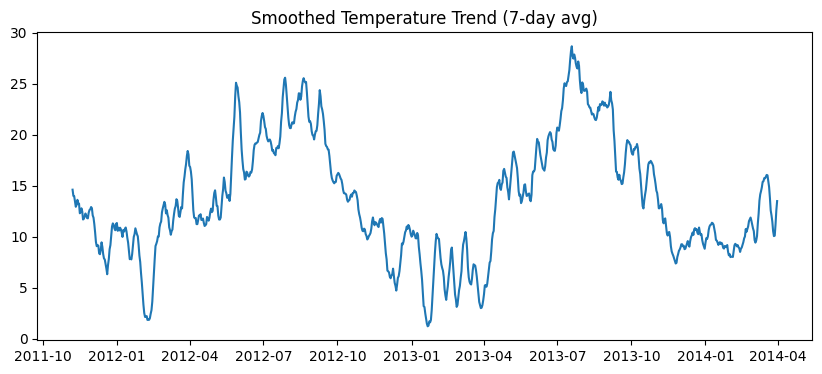

In [18]:
# In mid year the temperature is higher than start and end year
df['temp_smooth'] = df['temperatureMax'].rolling(window=7).mean()

plt.figure(figsize=(10,4))
plt.plot(df['day'], df['temp_smooth'])
plt.title("Smoothed Temperature Trend (7-day avg)")

<Axes: xlabel='temperatureMax', ylabel='Count'>

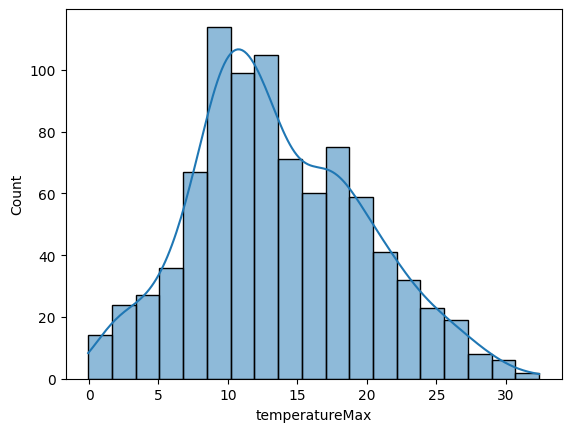

In [22]:
# The temperature distribution shows the range of environmental conditions experienced
# Insights - London mostly has moderate weather around 10-15 degree and high variance in weather
sns.histplot(df['temperatureMax'], kde=True)

<Axes: >

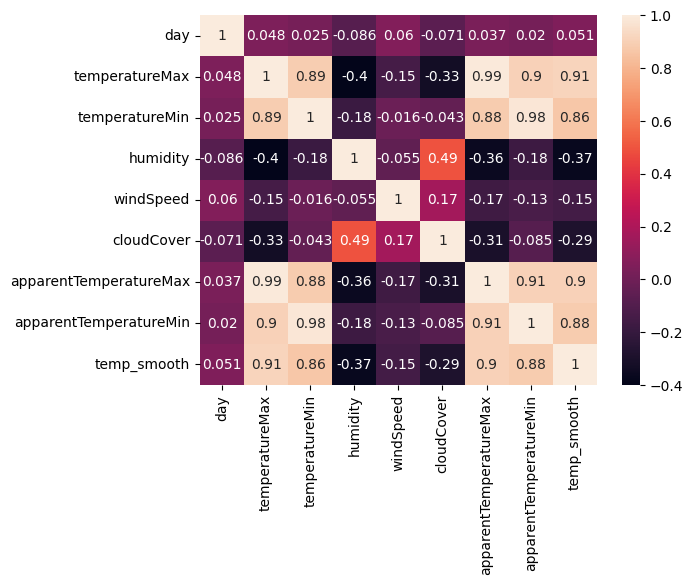

In [24]:
# Correlation analysis helps identify the most relevant weather features for energy prediction
# Insight - There is Strong correlation between temperatureMax and apparentTemperatureMax
#         - Similarily between temperatureMin and apparentTemperatureMin
#         - They are redundant
sns.heatmap(df.corr(), annot=True)